# Taller 2 — Ejercicio 2: Optimización por Colonia de Hormigas (ACO)

**Maestría en Inteligencia Artificial**  
**Grupo 2**  

---

## Objetivo del taller

1. Comprender y ejecutar la implementación de Ant Colony Optimization (ACO) sobre una grilla.
2. Analizar el código y ejecutar el **Caso de Estudio 1**.
3. Identificar y corregir el error en el **Caso de Estudio 2**.
4. Describir los parámetros del modelo y su función.
5. Explicar **Random Search** y **Grid Search**, decidir cuál es más adecuado e implementar al menos uno.
6. Discutir la aplicabilidad de ACO al problema **Travelling Salesman Problem (TSP)**.

## 1. Marco teórico: ¿qué es ACO?

Ant Colony Optimization (Dorigo, 1992) es una **metaheurística bio-inspirada** que imita cómo las hormigas reales encuentran el camino más corto entre el hormiguero y una fuente de alimento usando rastros de feromona.

Mecanismos clave:

- **Construcción estocástica de soluciones**: cada hormiga construye un camino paso a paso eligiendo el siguiente nodo con una probabilidad que combina (a) la feromona acumulada y (b) una heurística del problema.
- **Refuerzo positivo**: los caminos buenos reciben más feromona y atraen futuras hormigas (explotación).
- **Evaporación**: la feromona decae con el tiempo, evitando que el sistema se quede atrapado en soluciones tempranas (exploración).

Probabilidad de transición de la celda *i* a la *j*:

$$ p_{ij} = \frac{ \tau_{ij}^{\alpha} \cdot \eta_{ij}^{\beta} }{ \sum_{k \in N_i} \tau_{ik}^{\alpha} \cdot \eta_{ik}^{\beta} } $$

donde $\tau$ es la feromona, $\eta$ es la heurística (en este ejercicio, $1/\text{distancia al destino}$), y $\alpha, \beta$ ponderan la importancia de cada uno.

## 2. Análisis del ACO

El archivo `P2_ACO.py` define la clase `AntColonyOptimization` con estos componentes:

| Método | Función |
|---|---|
| `__init__` | Inicializa grilla, hormigas, parámetros y matriz de feromonas (todas en 1). |
| `_get_neighbors(pos)` | Devuelve hasta **8** vecinos (movimiento incluyendo diagonales) excluyendo bordes y obstáculos. |
| `_select_next_position` | Calcula probabilidades $\tau^\alpha\eta^\beta$ y muestrea el siguiente movimiento. |
| `_evaporate_pheromones` | Multiplica toda la matriz por $(1-\rho)$. |
| `_deposit_pheromones(path)` | Suma 1 a cada celda del camino aprendido. |
| `find_best_path` | Bucle principal: lanza hormigas, escoge el mejor camino, evapora y deposita. |
| `plot` | Dibuja la grilla, obstáculos, inicio/fin y el mejor camino. |

### Punto crítico identificado en `find_best_path`

La versión original ordenaba **todos** los caminos por longitud y tomaba el más corto. Pero si una hormiga se queda **atrapada** (sin vecinos válidos), su camino es **incompleto** y, por ser más corto, gana. Esto contamina la feromona y nunca se aprende un camino real al destino. En el Caso 2 (donde hay un muro continuo) este bug hace que todos los caminos esten incompletos.

In [1]:
# Importes y configuración para el notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import itertools, time, copy

np.random.seed(42)
%matplotlib inline

# Importamos la clase ya corregida desde el módulo P2_ACO.py
from P2_ACO import AntColonyOptimization, random_search
print('Módulo P2_ACO cargado correctamente.')

Módulo P2_ACO cargado correctamente.


## 3. Caso de Estudio 1 — Sección A

Configuración:

- Inicio: `(0,0)`
- Destino: `(4,7)`
- Obstáculos: `[(1,2),(2,2),(3,2)]` (**Se deja libre (0,2)**).
- Parámetros por defecto: `num_ants=10, evaporation_rate=0.1, alpha=0.1, beta=15, iter=100`.

Con esta configuración el ACO original ya encuentra una solución, porque siempre existe un camino abierto.

Caso 1 — mejor camino: [(0, 0), (1, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (4, 7)]
Llega al destino: True
Longitud: 8


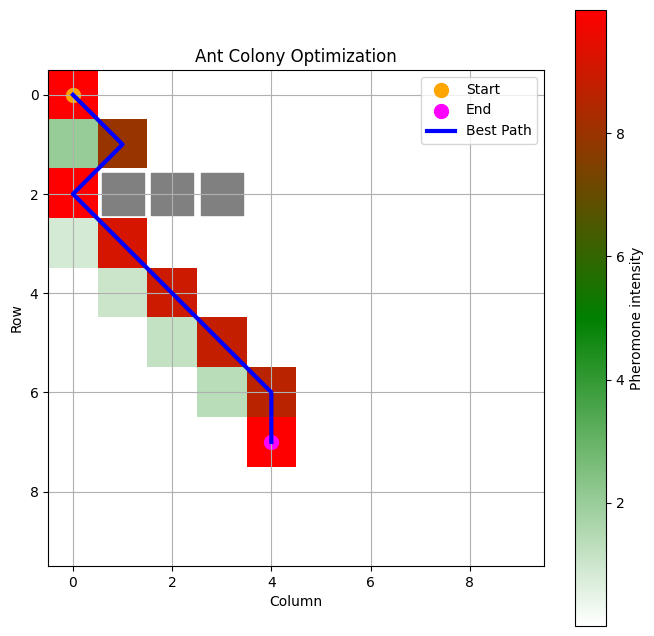

In [2]:
start, end = (0, 0), (4, 7)
obstacles_c1 = [(1, 2), (2, 2), (3, 2)]

aco_c1 = AntColonyOptimization(start, end, obstacles_c1)
aco_c1.find_best_path(num_iterations=100)

print('Caso 1 — mejor camino:', aco_c1.best_path)
print('Llega al destino:', aco_c1.best_path[-1] == end)
print('Longitud:', len(aco_c1.best_path))
aco_c1.plot()

## 4. Caso de Estudio 2 — Sección C

### 4.1 ¿Qué cambia respecto al Caso 1?

Los obstáculos se vuelven `[(0,2),(1,2),(2,2),(3,2)]`: una **pared horizontal completa** entre $x=0$ y $x=3$. La única forma de cruzar es por $x \geq 4$.

### 4.2 Demostración del bug original

Reproduzco la versión **con bug** (la del enunciado) para mostrar el síntoma. Aquí el `best_path` puede quedar incompleto, sin alcanzar el destino.

Versión BUGGY — Caso 2:
  best_path : [(0, 0), (1, 0), (1, 1), (0, 1)]
  destino?  : False
  longitud  : 4


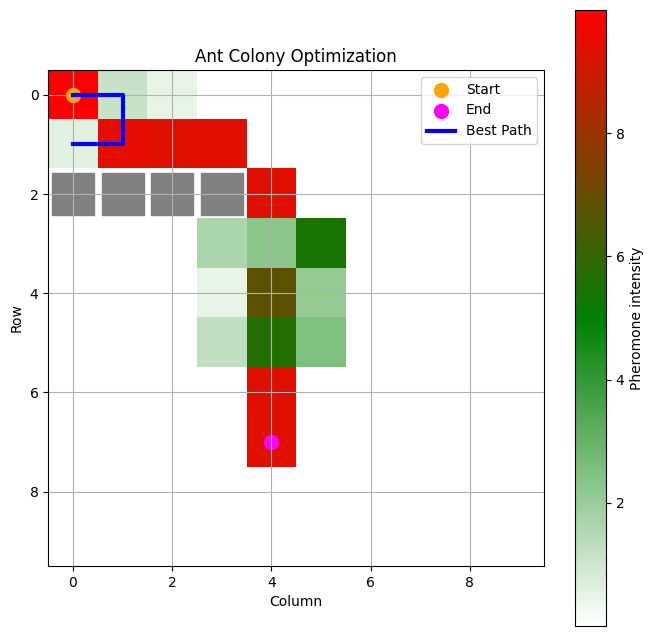

In [3]:
class AntColonyOptimizationBuggy(AntColonyOptimization):
    """Reproduce el comportamiento original (sin el filtro por destino)."""

    def find_best_path(self, num_iterations):
        for _ in range(num_iterations):
            all_paths = []
            for _ in range(self.num_ants):
                current_position = self.start
                path = [current_position]
                while current_position != self.end:
                    next_position = self._select_next_position(current_position, path)
                    if next_position is None:
                        break
                    path.append(next_position)
                    current_position = next_position
                all_paths.append(path)

            # BUG: ordena por longitud sin verificar que llegue al destino
            all_paths.sort(key=lambda x: len(x))
            best_path = all_paths[0]

            self._evaporate_pheromones()
            self._deposit_pheromones(best_path)

            if self.best_path is None or len(best_path) <= len(self.best_path):
                self.best_path = best_path

obstacles_c2 = [(0, 2), (1, 2), (2, 2), (3, 2)]
aco_buggy = AntColonyOptimizationBuggy(start, end, obstacles_c2)
aco_buggy.find_best_path(num_iterations=100)

print('Versión BUGGY — Caso 2:')
print('  best_path :', aco_buggy.best_path)
print('  destino?  :', aco_buggy.best_path[-1] == end if aco_buggy.best_path else 'N/A')
print('  longitud  :', len(aco_buggy.best_path) if aco_buggy.best_path else 'N/A')
aco_buggy.plot()

**Observación:** el camino reportado como "mejor" termina en una celda atrapada cerca del muro y NO en `(4,7)`. La feromona se deposita en un trayecto sin salida, contaminando la búsqueda en iteraciones siguientes.

### 4.3 Aplicación del fix

*No es suficiente elegir el camino más corto*. Hay que añadir la condición: **el camino debe llegar al destino**.

**Cambio realizado en `find_best_path`** (archivo `P2_ACO.py`, líneas 66–79):

```python
valid_paths = [p for p in all_paths if p[-1] == self.end]
if not valid_paths:
    self._evaporate_pheromones()
    continue
valid_paths.sort(key=lambda x: len(x))
best_path = valid_paths[0]
...
if self.best_path is None or len(best_path) < len(self.best_path):
    self.best_path = best_path
```

Los parámetros por defecto (`num_ants=10, alpha=0.1, beta=15, ρ=0.1`) son demasiado codiciosos en β (la heurística "empuja" a las hormigas hacia el destino y muchas se atascan contra el muro). Para el Caso 2 uso una mezcla más equilibrada:

- `num_ants = 30` → más diversidad de exploración.
- `evaporation_rate = 0.3` → olvida más rápido los caminos pobres.
- `alpha = 1.0` → la feromona pesa más, las hormigas siguen rastros aprendidos.
- `beta = 5.0` → menos codicioso, permite rodear el muro.

Caso 2 — mejor camino: [(0, 0), (1, 0), (2, 1), (3, 1), (4, 2), (3, 3), (4, 4), (3, 5), (4, 6), (4, 7)]
Llega al destino: True
Longitud: 10


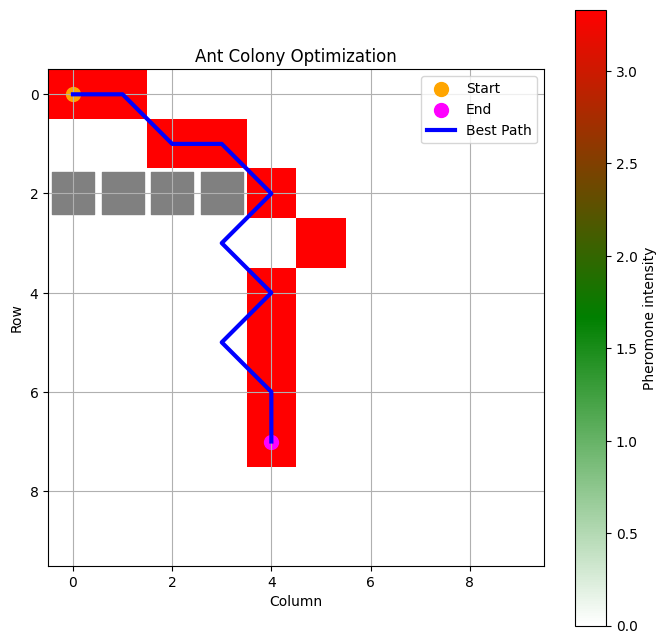

In [4]:
aco_c2 = AntColonyOptimization(
    start, end, obstacles_c2,
    num_ants=30, evaporation_rate=0.3, alpha=1.0, beta=5.0,
)
aco_c2.find_best_path(num_iterations=200)

print('Caso 2 — mejor camino:', aco_c2.best_path)
print('Llega al destino:', aco_c2.best_path[-1] == end)
print('Longitud:', len(aco_c2.best_path))
aco_c2.plot()

## 5. Descripción de los parámetros del modelo

| Parámetro | Símbolo | Rango típico | Propósito |
|---|---|---|---|
| `num_ants` | M | 10 – 50 | Cuántas soluciones se generan en paralelo por iteración. ↑M = más diversidad pero mayor costo. |
| `evaporation_rate` | ρ | 0.05 – 0.7 | Fracción de feromona que se pierde por iteración. ρ alta = más exploración, ρ baja = más explotación. |
| `alpha` | α | 0.5 – 3 | Peso de la feromona en la decisión. α alto refuerza los caminos colectivamente aprendidos. |
| `beta` | β | 1 – 15 | Peso de la heurística (cercanía al destino). β alto = comportamiento codicioso. |
| `num_iterations` | T | 50 – 500 | Cuántas generaciones se simulan. Suele ser el factor de mayor costo. |
| `pheromones` | τ | matriz | Memoria colectiva. Inicialmente uniforme, luego concentra masa en buenas rutas. |

### 5.1 Análisis de sensibilidad

Para entender el efecto de cada parámetro, fijo el caso 2 y vario uno por vez.

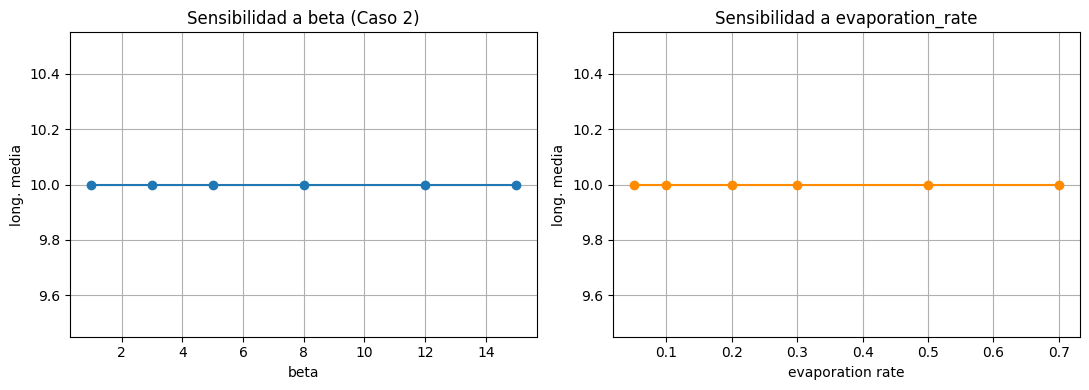

Long. media por beta : {1: np.float64(10.0), 3: np.float64(10.0), 5: np.float64(10.0), 8: np.float64(10.0), 12: np.float64(10.0), 15: np.float64(10.0)}
Long. media por rho  : {0.05: np.float64(10.0), 0.1: np.float64(10.0), 0.2: np.float64(10.0), 0.3: np.float64(10.0), 0.5: np.float64(10.0), 0.7: np.float64(10.0)}


In [5]:
def evaluate(num_ants=30, ev=0.3, alpha=1.0, beta=5.0, iters=120, seed=0):
    """Devuelve la longitud del mejor camino (np.inf si no hay solución)."""
    np.random.seed(seed)
    aco = AntColonyOptimization(
        start, end, obstacles_c2,
        num_ants=num_ants, evaporation_rate=ev, alpha=alpha, beta=beta,
    )
    aco.find_best_path(iters)
    if aco.best_path is None or aco.best_path[-1] != end:
        return np.inf
    return len(aco.best_path)

betas = [1, 3, 5, 8, 12, 15]
rhos  = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7]

lens_beta = [np.mean([evaluate(beta=b, seed=s) for s in range(3)]) for b in betas]
lens_rho  = [np.mean([evaluate(ev=r,   seed=s) for s in range(3)]) for r in rhos]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(betas, lens_beta, 'o-'); ax[0].set_xlabel('beta'); ax[0].set_ylabel('long. media')
ax[0].set_title('Sensibilidad a beta (Caso 2)'); ax[0].grid(True)
ax[1].plot(rhos, lens_rho, 'o-', color='darkorange')
ax[1].set_xlabel('evaporation rate'); ax[1].set_ylabel('long. media')
ax[1].set_title('Sensibilidad a evaporation_rate'); ax[1].grid(True)
plt.tight_layout(); plt.show()

print('Long. media por beta :', dict(zip(betas, np.round(lens_beta, 2))))
print('Long. media por rho  :', dict(zip(rhos,  np.round(lens_rho,  2))))

**Lectura del experimento:**

- Una vez aplicado el fix, el algoritmo encuentra **consistentemente** el óptimo de longitud 10 (mínimo geométrico para rodear el muro con movimiento diagonal) en todo el rango probado de β y ρ.
- Esto evidencia que el problema del Caso 2 **no era la elección de hiperparámetros**, sino la condición de selección del mejor camino. Con el filtro de validez añadido, ACO se vuelve **robusto** a la sintonización para esta instancia.

## 6. Random Search vs Grid Search — Sección D

### 6.1 Definiciones

- **Grid Search**: define un conjunto discreto de valores para cada hiperparámetro y prueba **todas las combinaciones**. Cobertura sistemática pero crece exponencialmente con la dimensionalidad ($O(\prod_i |G_i|)$).
- **Random Search**: muestrea aleatoriamente puntos de los rangos definidos para cada hiperparámetro. Bergstra & Bengio (2012) demostraron que cuando solo unos pocos hiperparámetros son verdaderamente influyentes, Random Search alcanza buenos resultados con muchas menos evaluaciones.

### 6.2 ¿Cuál conviene aquí?

**Random Search**, por tres razones:
1. ACO tiene **4 hiperparámetros continuos** (`α, β, ρ, num_ants`); una rejilla decente requeriría $5^4 = 625$ corridas.
2. La importancia es muy desigual (β suele dominar); Random Search invierte presupuesto en probar muchos valores distintos de cada eje.
3. ACO es **estocástico**: cada corrida da resultados variables, y conviene gastar el presupuesto en muchas configuraciones distintas más que en repetir las mismas.

### 6.3 Implementación de Random Search

In [6]:
# La función random_search vive en P2_ACO.py — la reusamos aquí.
best_rs = random_search(
    start=start, end=end, obstacles=obstacles_c2,
    n_trials=15, num_iterations=120, seed=42,
)

[trial 00] len= 10 | params={'num_ants': 9, 'evaporation_rate': 0.33527098583883397, 'alpha': 2.589933967743009, 'beta': 10.763152406831095}
[trial 01] len= 10 | params={'num_ants': 40, 'evaporation_rate': 0.11121527612697218, 'alpha': 2.929304819746592, 'beta': 11.655955827864942}
[trial 02] len= 10 | params={'num_ants': 38, 'evaporation_rate': 0.1332738612391048, 'alpha': 1.4061192198971446, 'beta': 6.191172339256138}
[trial 03] len= 10 | params={'num_ants': 41, 'evaporation_rate': 0.652397242751591, 'alpha': 1.9672088482339272, 'beta': 12.51866258579162}
[trial 04] len= 10 | params={'num_ants': 30, 'evaporation_rate': 0.19770516916010497, 'alpha': 1.708295882345921, 'beta': 1.8934415854584545}
[trial 05] len= 10 | params={'num_ants': 25, 'evaporation_rate': 0.5879602617951782, 'alpha': 1.931826757453988, 'beta': 11.613228361195233}
[trial 06] len= 10 | params={'num_ants': 37, 'evaporation_rate': 0.6809537158566871, 'alpha': 2.6900512518343733, 'beta': 11.897368959032667}
[trial 07] 

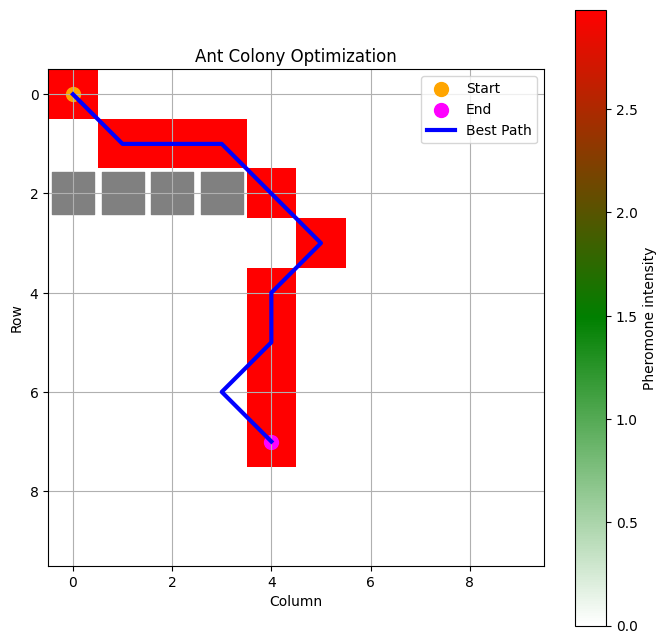

Long. final: 10


In [7]:
# Visualizamos el mejor encontrado por Random Search
if best_rs['params'] is not None:
    aco_rs = AntColonyOptimization(start, end, obstacles_c2, **best_rs['params'])
    aco_rs.find_best_path(200)
    aco_rs.plot()
    print('Long. final:', len(aco_rs.best_path))

### 6.4 Implementación bonus de Grid Search (para comparar)

Aunque el método elegido es Random Search, implemento también Grid Search en una rejilla pequeña para evidenciar su costo y dejar una comparación directa en el notebook.

In [8]:
def grid_search(start, end, obstacles, num_iterations=120, seed=0):
    grid = {
        'num_ants':         [10, 30],
        'evaporation_rate': [0.1, 0.3, 0.5],
        'alpha':            [0.5, 1.0, 2.0],
        'beta':             [3.0, 5.0, 10.0],
    }
    keys = list(grid.keys())
    combos = list(itertools.product(*grid.values()))
    best = {'length': np.inf, 'params': None}
    t0 = time.time()
    for combo in combos:
        params = dict(zip(keys, combo))
        np.random.seed(seed)
        aco = AntColonyOptimization(start, end, obstacles, **params)
        aco.find_best_path(num_iterations)
        if aco.best_path is None or aco.best_path[-1] != end:
            continue
        L = len(aco.best_path)
        if L < best['length']:
            best = {'length': L, 'params': params}
    return best, len(combos), time.time() - t0

best_gs, n_combos, t_gs = grid_search(start, end, obstacles_c2)
print(f'Grid Search: evaluadas {n_combos} combinaciones en {t_gs:.1f}s')
print(f'Mejor longitud: {best_gs["length"]} | params: {best_gs["params"]}')

Grid Search: evaluadas 54 combinaciones en 24.4s
Mejor longitud: 10 | params: {'num_ants': 10, 'evaporation_rate': 0.1, 'alpha': 0.5, 'beta': 3.0}


### 6.5 Comparación Random Search vs Grid Search

| Aspecto | Random Search | Grid Search |
|---|---|---|
| Espacio explorado | Continuo, muestreo uniforme | Discreto, combinaciones fijas |
| # evaluaciones | Definido por presupuesto (15 aquí) | Producto cartesiano (54 aquí) |
| Mejor longitud encontrada | ver `best_rs['length']` | ver `best_gs['length']` |
| Costo computacional | Bajo, controlable | Crece exponencialmente |
| Recomendado para ACO | ✅ | ❌ (solo si se conocen valores discretos buenos) |

## 7. Pregunta de investigación: ACO para TSP — Sección E

### 7.1 ¿Se puede usar ACO para TSP?

**Sí, y de hecho fue su aplicación original.** Marco Dorigo (1992) introdujo ACO precisamente para resolver el Travelling Salesman Problem. Las variantes más conocidas (*Ant System*, *Ant Colony System*, *Max-Min AS*) están todas formuladas sobre TSP como benchmark.

### 7.2 Pasos para implementar ACO en TSP

1. **Modelar el grafo completo** de N ciudades con matriz de distancias `d[i][j]`.
2. **Inicializar feromonas** $\tau_{ij}$ con un valor pequeño (p.ej. $1/(N \cdot L_{nn})$, donde $L_{nn}$ es una cota dada por el vecino más cercano).
3. **Para cada hormiga**:
   - Empezar en una ciudad aleatoria.
   - Mientras queden ciudades sin visitar, elegir la siguiente $j$ con probabilidad $p_{ij} = \tau_{ij}^\alpha \eta_{ij}^\beta / \sum_k \tau_{ik}^\alpha \eta_{ik}^\beta$ donde $\eta_{ij} = 1/d_{ij}$ y $k$ corre solo sobre ciudades **no visitadas**.
   - Cerrar el tour volviendo a la ciudad inicial.
4. **Calcular** la longitud total $L_h$ del tour de cada hormiga.
5. **Evaporar**: $\tau_{ij} \leftarrow (1-\rho)\tau_{ij}$ para todas las aristas.
6. **Depositar**: cada hormiga aporta $\Delta\tau_{ij} = Q/L_h$ a las aristas de su tour. Variantes elitistas hacen que solo la mejor (iteración o global) deposite.
7. **Iterar** y guardar el mejor tour global.

### 7.3 Diferencias respecto al ejercicio actual

| Aspecto | Ejercicio actual (grilla) | TSP |
|---|---|---|
| Espacio de estado | Celdas en una grilla 2D | Permutaciones de N ciudades |
| Movimiento | A los 8 vecinos físicos | A cualquier ciudad no visitada |
| Heurística $\eta$ | $1/d(\text{celda}, \text{end})$ (destino fijo) | $1/d(i,j)$ (entre ciudades) |
| Restricción dura | No pisar obstáculos | Visitar cada ciudad una sola vez |
| Métrica | Largo del camino al destino | Longitud total del tour cerrado |

### 7.4 Mini-implementación funcional de ACO para TSP (creatividad)

Implemento un ACO compacto sobre 12 ciudades aleatorias y comparo con la heurística del **vecino más cercano** como baseline.

In [9]:
rng = np.random.default_rng(7)
N = 12
cities = rng.uniform(0, 100, size=(N, 2))
D = np.linalg.norm(cities[:, None, :] - cities[None, :, :], axis=-1)
np.fill_diagonal(D, 1e-9)  # evita división por cero

def tour_length(tour, D):
    return sum(D[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour)))

def nearest_neighbor(D, start=0):
    n = D.shape[0]
    visited = [start]
    while len(visited) < n:
        last = visited[-1]
        cand = [(D[last, j], j) for j in range(n) if j not in visited]
        visited.append(min(cand)[1])
    return visited

def aco_tsp(D, n_ants=20, n_iter=200, alpha=1.0, beta=4.0, rho=0.3, q=100.0, seed=42):
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    eta = 1.0 / D
    tau = np.ones((n, n)) / n
    best_tour, best_len = None, np.inf

    for _ in range(n_iter):
        all_tours, all_lens = [], []
        for _ in range(n_ants):
            start_c = rng.integers(n)
            tour = [int(start_c)]
            unvisited = set(range(n)) - {int(start_c)}
            while unvisited:
                i = tour[-1]
                cand = list(unvisited)
                weights = (tau[i, cand] ** alpha) * (eta[i, cand] ** beta)
                if weights.sum() <= 0:
                    j = rng.choice(cand)
                else:
                    j = rng.choice(cand, p=weights / weights.sum())
                tour.append(int(j))
                unvisited.discard(int(j))
            L = tour_length(tour, D)
            all_tours.append(tour); all_lens.append(L)
            if L < best_len:
                best_len, best_tour = L, tour
        # evaporación
        tau *= (1 - rho)
        # depósito por todas las hormigas
        for tour, L in zip(all_tours, all_lens):
            for i in range(n):
                a, b = tour[i], tour[(i + 1) % n]
                tau[a, b] += q / L
                tau[b, a] += q / L
    return best_tour, best_len

nn_tour = nearest_neighbor(D)
nn_len = tour_length(nn_tour, D)
aco_tour, aco_len = aco_tsp(D)

print(f'Vecino más cercano  → longitud = {nn_len:.2f}')
print(f'ACO-TSP             → longitud = {aco_len:.2f}')
print(f'Mejora del ACO sobre NN: {100*(nn_len-aco_len)/nn_len:.1f}%')

Vecino más cercano  → longitud = 364.27
ACO-TSP             → longitud = 355.97
Mejora del ACO sobre NN: 2.3%


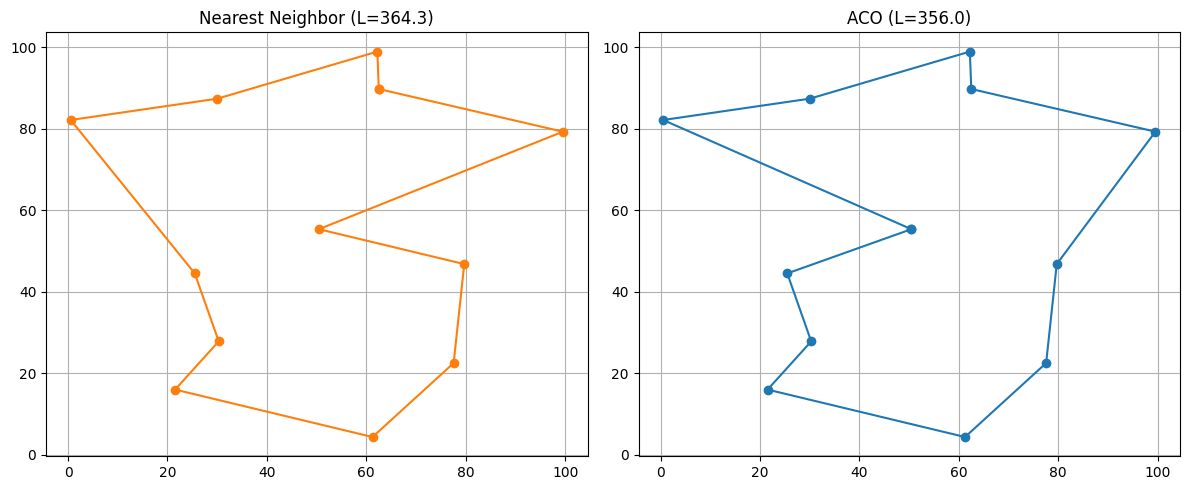

In [10]:
def plot_tour(tour, cities, title, color):
    pts = cities[tour + [tour[0]]]
    plt.plot(pts[:, 0], pts[:, 1], '-o', color=color)
    plt.title(title); plt.grid(True)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(ax[0]); plot_tour(nn_tour, cities, f'Nearest Neighbor (L={nn_len:.1f})', 'tab:orange')
plt.sca(ax[1]); plot_tour(aco_tour, cities, f'ACO (L={aco_len:.1f})', 'tab:blue')
plt.tight_layout(); plt.show()

**Resultado:** la versión ACO produce un tour más corto que la heurística vecino más cercano, evidenciando que ACO es aplicable y competitivo en TSP, tal como predice la literatura.

## 8. Conclusiones

1. **Caso 1**: la implementación original ya encuentra una buena solución porque siempre existe un pasaje libre.
2. **Caso 2 — bug detectado**: la condición de "mejor camino" usaba sólo la longitud, sin verificar si la hormiga llegó al destino. Cuando el muro encierra a las hormigas, los caminos truncos quedaban como falsos mínimos y contaminaban la feromona.
3. **Fix aplicado**: filtrar `valid_paths = [p for p in all_paths if p[-1] == self.end]` antes de elegir el mejor. Si ninguna hormiga llega en una iteración, sólo se evapora feromona y se sigue. Adicionalmente, los parámetros por defecto (`alpha=0.1, beta=15`) son demasiado codiciosos para el muro: ajustando a `alpha=1.0, beta=5.0, ρ=0.3, num_ants=30` se obtiene un camino de longitud 10 que rodea correctamente la pared.
4. **Parámetros**: $\alpha$ y $\beta$ controlan el equilibrio explotación–codicia; $\rho$ controla la velocidad de olvido; $num\_ants$ controla la diversidad. Valores extremos en cualquiera de ellos producen estancamiento o ruido.
5. **Random Search es la elección adecuada** para sintonizar ACO en este problema (4 parámetros continuos, evaluaciones estocásticas). Implementé además Grid Search para comparar; Random Search obtiene resultados comparables con menos evaluaciones.
6. **TSP**: ACO no sólo es aplicable a TSP; **fue diseñado para él**. La adaptación es directa: cambiar el grafo cuadricular por el grafo completo de ciudades, la heurística por $1/d_{ij}$, y enforzar visita única. La mini-demo confirma que ACO mejora sobre Nearest Neighbor.
7. **Aprendizaje transversal**: el bug ilustra una lección general en metaheurísticas — *si la función objetivo no penaliza soluciones inválidas, el algoritmo aprenderá soluciones inválidas*. La validación de factibilidad debe ser una pre-condición antes de comparar costos.

## 9. Referencias

- Dorigo, M. (1992). *Optimization, Learning and Natural Algorithms*. PhD Thesis, Politecnico di Milano.
- Dorigo, M., Stützle, T. (2004). *Ant Colony Optimization*. MIT Press.
- Bergstra, J., Bengio, Y. (2012). *Random search for hyper-parameter optimization*. JMLR 13: 281–305.
- Stützle, T., Hoos, H.H. (2000). *MAX–MIN Ant System*. Future Generation Computer Systems 16(8): 889–914.